# Machine Learning Based Buyer Segmentation and Investment Profiling for Real Estate Market Intelligence

## Exploratory Data Analysis (EDA)

### Objectives
- Understand the structure of the dataset
- Check data quality and missing values
- Analyze buyer demographics
- Explore geographic and investment patterns
- Generate business insights for clustering

In [44]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# Plot Settings
plt.rcParams["figure.figsize"] = (8,5)
plt.rcParams["figure.dpi"] = 120

sns.set_style("whitegrid")

In [45]:
master = pd.read_csv("../data/master_dataset.csv")

In [46]:
print("Rows :", master.shape[0])
print("Columns :", master.shape[1])

Rows : 2000
Columns : 18


### Observation

The dataset contains buyer-level information along with aggregated property purchase details. Each row represents one unique buyer.

In [47]:
master.head()

,client_id,client_type,first_name,last_name,date_of_birth,gender,country,region,acquisition_purpose,satisfaction_score,loan_applied,referral_channel,age,client_ref,total_properties,total_investment,average_sale_price,average_floor_area
0,C0001,Individual,Kareem,Liu,1968-11-05,F,USA,California,Home,4,Yes,Website,57,C0001,4,1246764.72,311691.180000,983.885000
1,C0002,Individual,Trystan,Oconnor,1962-11-26,M,USA,California,Home,1,No,Website,63,C0002,5,1841095.93,368219.186000,1187.942000
2,C0003,Individual,Kale,Gay,1959-07-04,M,USA,California,Home,4,Yes,Agency,67,C0003,5,1661457.59,332291.518000,1058.110000
3,C0004,Individual,Russell,Gross,1959-11-25,M,USA,California,Home,5,No,Website,66,C0004,6,1608263.51,268043.918333,937.103333
4,C0005,Company,Marleez,Co,1976-02-28,M,USA,California,Investment,5,No,Website,50,C0005,13,3653385.38,281029.644615,927.296154


### Observation

The dataset combines customer demographic information with aggregated investment metrics such as total investment, average sale price and total properties purchased.

In [48]:
master.info()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   client_id            2000 non-null   str    
 1   client_type          2000 non-null   str    
 2   first_name           2000 non-null   str    
 3   last_name            2000 non-null   str    
 4   date_of_birth        2000 non-null   str    
 5   gender               2000 non-null   str    
 6   country              2000 non-null   str    
 7   region               2000 non-null   str    
 8   acquisition_purpose  2000 non-null   str    
 9   satisfaction_score   2000 non-null   int64  
 10  loan_applied         2000 non-null   str    
 11  referral_channel     2000 non-null   str    
 12  age                  2000 non-null   int64  
 13  client_ref           2000 non-null   str    
 14  total_properties     2000 non-null   int64  
 15  total_investment     2000 non-null   float64
 16 

### Observation

This step verifies the data types of every feature and ensures that numerical and categorical variables are correctly identified before analysis.

In [49]:
master.isnull().sum()

client_id              0
client_type            0
first_name             0
last_name              0
date_of_birth          0
gender                 0
country                0
region                 0
acquisition_purpose    0
satisfaction_score     0
loan_applied           0
referral_channel       0
age                    0
client_ref             0
total_properties       0
total_investment       0
average_sale_price     0
average_floor_area     0
dtype: int64

### Observation

Missing values indicate buyers who have not yet completed any successful property purchase, resulting in unavailable investment-related fields.

In [50]:
missing = (
    master.isnull()
          .sum()
          .reset_index()
)

missing.columns = ["Column","Missing Values"]

missing["Percentage"] = (
    missing["Missing Values"]
    / len(master)
    *100
)

missing

,Column,Missing Values,Percentage
0,client_id,0,0.0
1,client_type,0,0.0
2,first_name,0,0.0
3,last_name,0,0.0
4,date_of_birth,0,0.0
5,gender,0,0.0
6,country,0,0.0
7,region,0,0.0
8,acquisition_purpose,0,0.0
9,satisfaction_score,0,0.0


In [51]:
print("Duplicate Rows :", master.duplicated().sum())

Duplicate Rows : 0


### Observation

Checking duplicate records ensures that each buyer is represented only once in the master dataset.

In [52]:
master.describe()

,satisfaction_score,age,total_properties,total_investment,average_sale_price,average_floor_area
count,2000.000000,2000.000000,2000.0000,2.000000e+03,2000.000000,2000.000000
mean,3.029000,55.741000,3.6525,1.260375e+06,347089.955869,1147.479668
std,1.413562,17.354265,0.8397,3.478307e+05,69721.821814,219.922587
min,1.000000,25.000000,3.0000,4.636120e+05,154537.316667,564.010000
25%,2.000000,41.000000,3.0000,1.025238e+06,295807.677708,984.952500
50%,3.000000,56.000000,4.0000,1.220893e+06,341523.383333,1129.176667
75%,4.000000,70.000000,4.0000,1.441974e+06,390843.316875,1296.562500
max,5.000000,95.000000,13.0000,3.653385e+06,563423.500000,1800.450000


### Observation

The summary statistics provide an overview of the distribution of numerical features such as age, satisfaction score, investment amount and property area.

In [53]:
master.describe(include="object")

C:\Users\aayus\AppData\Local\Temp\ipykernel_18724\4133792708.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  master.describe(include="object")


,client_id,client_type,first_name,last_name,date_of_birth,gender,country,region,acquisition_purpose,loan_applied,referral_channel,client_ref
count,2000,2000,2000,2000,2000,2000,2000,2000,2000,2000,2000,2000
unique,2000,2,337,224,1889,2,10,57,2,2,3,2000
top,C0001,Individual,Carl,Co,1967-04-13,M,USA,California,Home,No,Website,C0001
freq,1,1897,24,103,3,1012,1538,633,1385,1264,1103,1


### Observation

Categorical statistics summarize the frequency and diversity of buyer characteristics including client type, country, acquisition purpose and referral channel.

In [54]:
master.dtypes

client_id                  str
client_type                str
first_name                 str
last_name                  str
date_of_birth              str
gender                     str
country                    str
region                     str
acquisition_purpose        str
satisfaction_score       int64
loan_applied               str
referral_channel           str
age                      int64
client_ref                 str
total_properties         int64
total_investment       float64
average_sale_price     float64
average_floor_area     float64
dtype: object

In [55]:
numerical_columns = master.select_dtypes(include=np.number).columns

print(numerical_columns)

Index(['satisfaction_score', 'age', 'total_properties', 'total_investment',
       'average_sale_price', 'average_floor_area'],
      dtype='str')


In [56]:
categorical_columns = master.select_dtypes(include="object").columns

print(categorical_columns)

Index(['client_id', 'client_type', 'first_name', 'last_name', 'date_of_birth',
       'gender', 'country', 'region', 'acquisition_purpose', 'loan_applied',
       'referral_channel', 'client_ref'],
      dtype='str')


C:\Users\aayus\AppData\Local\Temp\ipykernel_18724\1126413628.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = master.select_dtypes(include="object").columns


In [57]:
for col in categorical_columns:
    print("="*50)
    print(col)
    print(master[col].value_counts())

client_id
client_id
C0001    1
C0002    1
C0003    1
C0004    1
C0005    1
        ..
C1996    1
C1997    1
C1998    1
C1999    1
C2000    1
Name: count, Length: 2000, dtype: int64
client_type
client_type
Individual    1897
Company        103
Name: count, dtype: int64
first_name
first_name
Carl       24
Gerald     20
Sarah      19
Jason      19
William    19
           ..
Apex        1
Peerex      1
Jeremy      1
Nexus       1
Halcyon     1
Name: count, Length: 337, dtype: int64
last_name
last_name
Co            103
Howard         39
Hansen         34
Morales        34
Cox            33
             ... 
Singh           1
Campos          1
Stephenson      1
Poole           1
Bright          1
Name: count, Length: 224, dtype: int64
date_of_birth
date_of_birth
1967-04-13    3
1993-06-14    3
1995-12-11    3
1975-03-27    3
1973-10-24    3
             ..
1993-05-03    1
1992-06-20    1
1942-09-27    1
1963-09-13    1
1944-06-15    1
Name: count, Length: 1889, dtype: int64
gender
gender
M

## Part 1 Conclusion

The dataset has been successfully loaded and inspected.

Key Findings:

- Dataset structure verified.
- Numerical and categorical features identified.
- Missing values inspected.
- Duplicate records checked.
- Summary statistics generated.
- Dataset is ready for detailed exploratory analysis.

# Buyer Demographics & Geographic Analysis

This section analyzes the demographic characteristics and geographic distribution of buyers to understand the customer base and identify high-potential market segments.

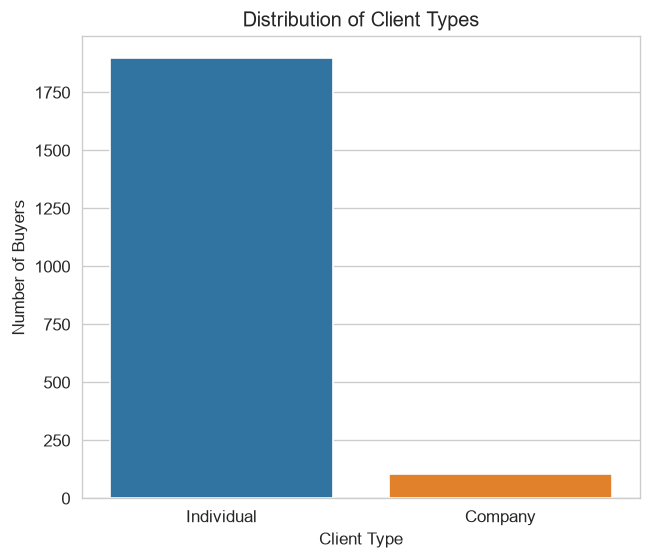

In [58]:
plt.figure(figsize=(6,5))

sns.countplot(
    data=master,
    x="client_type",
    hue="client_type",
    legend=False
)

plt.title("Distribution of Client Types")
plt.xlabel("Client Type")
plt.ylabel("Number of Buyers")

plt.show()

### Business Insight

- This chart compares Individual and Company buyers.
- Understanding the buyer composition helps design targeted marketing strategies for different customer segments.

In [59]:
client_percent = (
    master["client_type"]
    .value_counts(normalize=True)
    *100
).round(2)

client_percent

client_type
Individual    94.85
Company        5.15
Name: proportion, dtype: float64

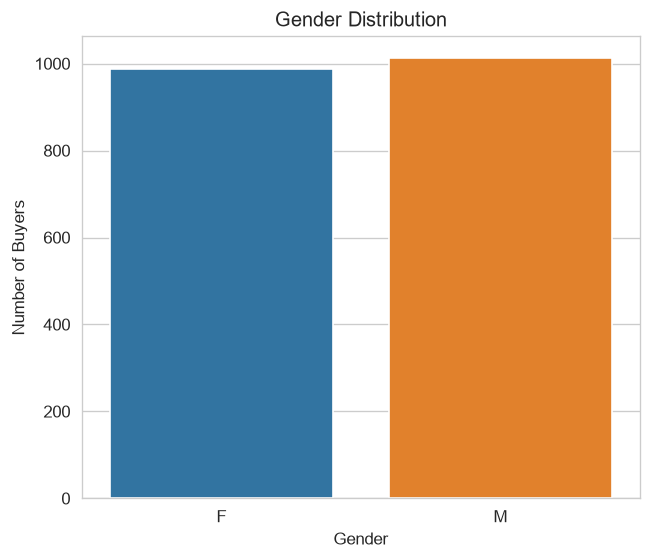

In [60]:
plt.figure(figsize=(6,5))

sns.countplot(
    data=master,
    x="gender",
    hue="gender",
    legend=False
)

plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Number of Buyers")

plt.show()

### Business Insight

- This visualization shows the gender composition of buyers.
- It helps evaluate whether marketing campaigns are reaching diverse customer groups.

In [61]:
gender_percent = (
    master["gender"]
    .value_counts(normalize=True)
    *100
).round(2)

gender_percent

gender
M    50.6
F    49.4
Name: proportion, dtype: float64

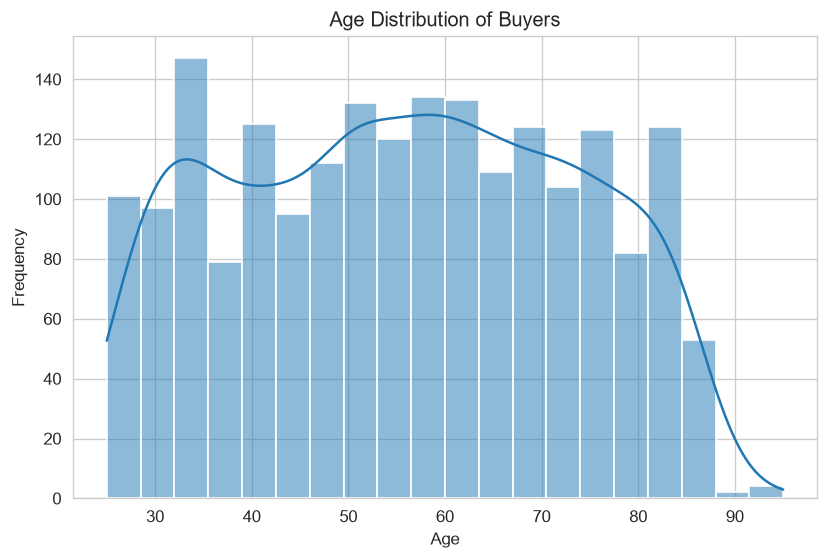

In [62]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=master,
    x="age",
    bins=20,
    kde=True
)

plt.title("Age Distribution of Buyers")
plt.xlabel("Age")
plt.ylabel("Frequency")

plt.show()

### Business Insight

- This distribution highlights the dominant buyer age groups.
- It helps identify the primary target audience for residential and investment properties.

In [63]:
master["age"].describe()

count    2000.000000
mean       55.741000
std        17.354265
min        25.000000
25%        41.000000
50%        56.000000
75%        70.000000
max        95.000000
Name: age, dtype: float64

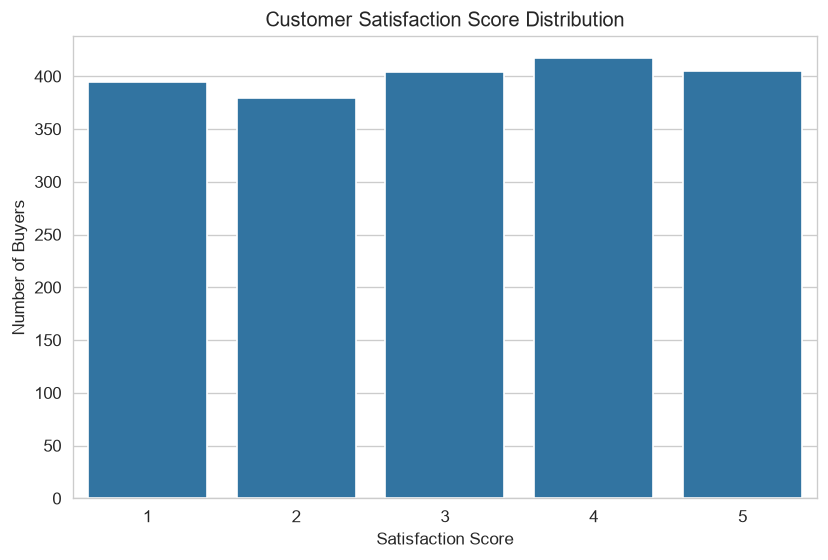

In [64]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=master,
    x="satisfaction_score"
)

plt.title("Customer Satisfaction Score Distribution")
plt.xlabel("Satisfaction Score")
plt.ylabel("Number of Buyers")

plt.show()

### Business Insight

- Customer satisfaction provides an indication of buyer experience.
- Higher satisfaction scores suggest stronger customer retention potential.

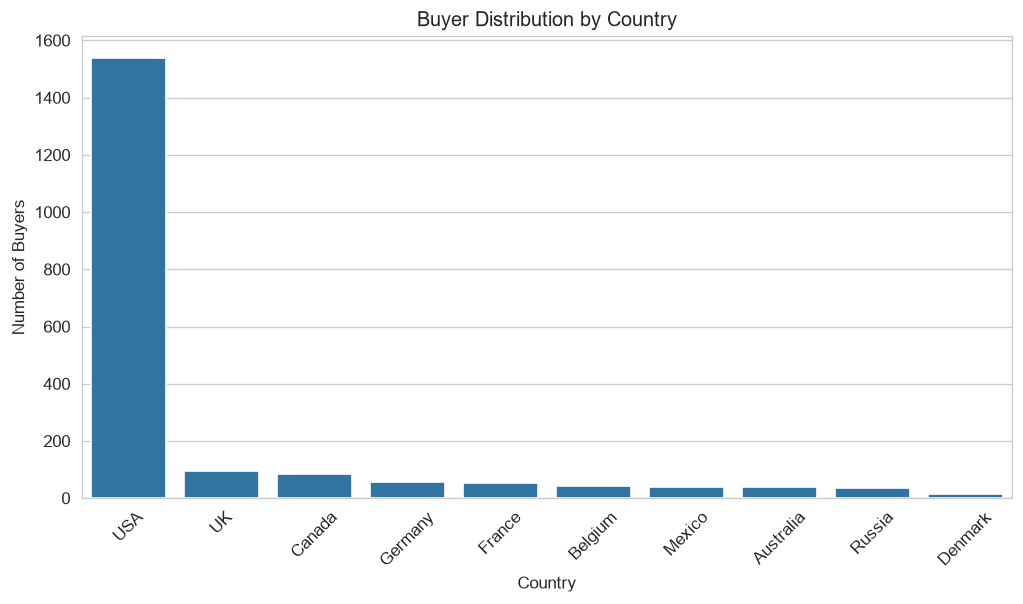

In [65]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=master,
    x="country",
    order=master["country"].value_counts().index
)

plt.title("Buyer Distribution by Country")
plt.xlabel("Country")
plt.ylabel("Number of Buyers")

plt.xticks(rotation=45)

plt.show()

### Business Insight

- This chart identifies countries contributing the highest number of buyers.
- Geographic insights support international marketing and expansion decisions.

In [66]:
master["country"].value_counts().head(10)

country
USA          1538
UK             95
Canada         85
Germany        56
France         53
Belgium        43
Mexico         40
Australia      39
Russia         36
Denmark        15
Name: count, dtype: int64

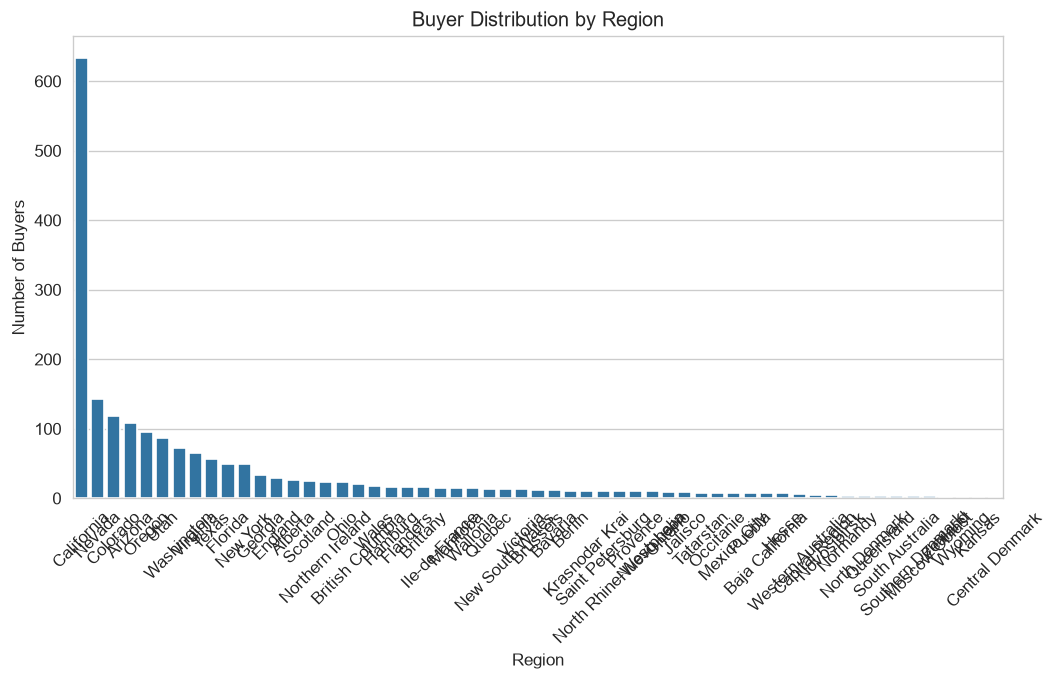

In [67]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=master,
    x="region",
    order=master["region"].value_counts().index
)

plt.title("Buyer Distribution by Region")
plt.xlabel("Region")
plt.ylabel("Number of Buyers")

plt.xticks(rotation=45)

plt.show()

### Business Insight

- Regional analysis identifies high-demand real estate markets.
- This information supports location-specific investment strategies.

In [68]:
(
    master["region"]
    .value_counts(normalize=True)
    *100
).round(2)

region
California                31.65
Nevada                     7.15
Colorado                   5.90
Arizona                    5.40
Oregon                     4.80
Utah                       4.35
Washington                 3.65
Virginia                   3.25
Texas                      2.80
Florida                    2.50
New York                   2.45
Georgia                    1.70
England                    1.45
Alberta                    1.35
Scotland                   1.25
Northern Ireland           1.20
Ohio                       1.20
British Columbia           1.00
Wales                      0.85
Hamburg                    0.80
Flanders                   0.80
Brittany                   0.80
Ile-de-France              0.75
Manitoba                   0.75
Wallonia                   0.75
Quebec                     0.70
New South Wales            0.65
Victoria                   0.65
Brussels                   0.60
Bavaria                    0.60
Berlin                     0.55
K

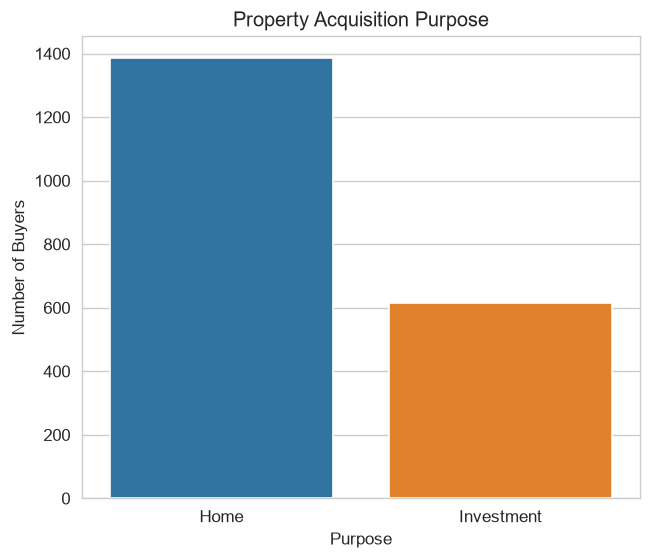

In [69]:
plt.figure(figsize=(6,5))

sns.countplot(
    data=master,
    x="acquisition_purpose",
    hue="acquisition_purpose",
    legend=False
)

plt.title("Property Acquisition Purpose")
plt.xlabel("Purpose")
plt.ylabel("Number of Buyers")

plt.show()

### Business Insight

- Buyers may purchase properties either for personal use or investment.
- Understanding purchase intent helps optimize sales and promotional strategies.

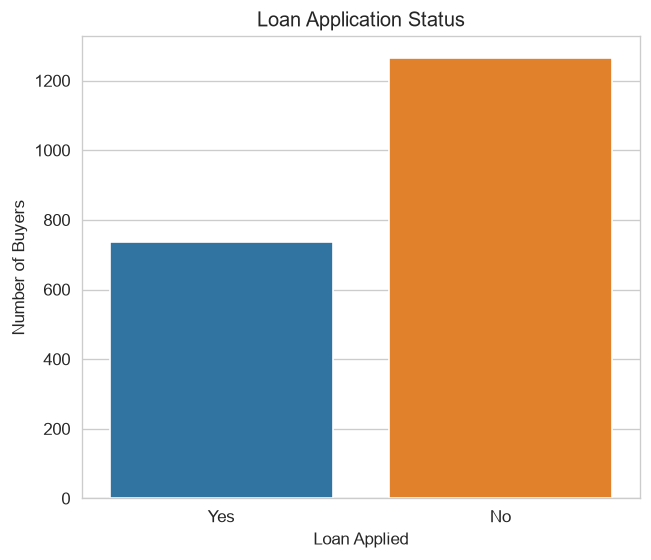

In [70]:
plt.figure(figsize=(6,5))

sns.countplot(
    data=master,
    x="loan_applied",
    hue="loan_applied",
    legend=False
)

plt.title("Loan Application Status")
plt.xlabel("Loan Applied")
plt.ylabel("Number of Buyers")

plt.show()

### Business Insight

- Loan dependency indicates financing behavior among buyers.
- Financial institutions and developers can use this insight to design suitable financing plans.

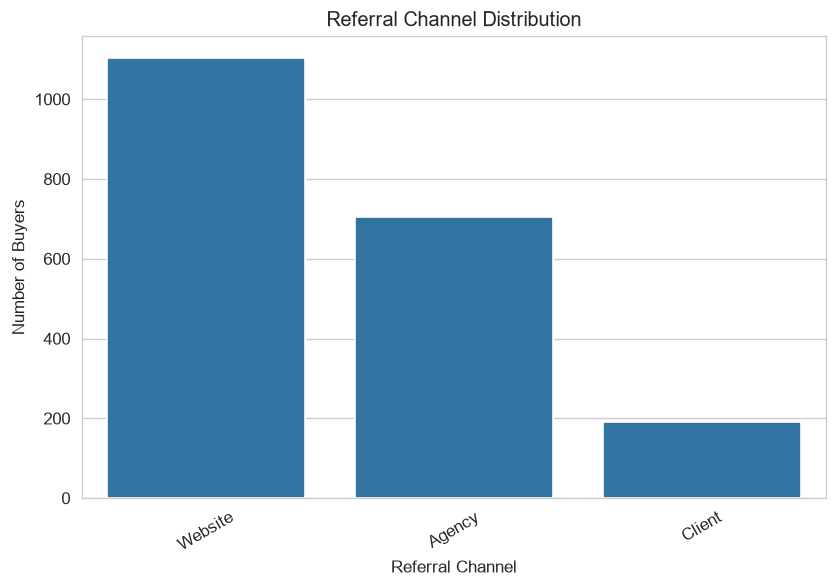

In [71]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=master,
    x="referral_channel",
    order=master["referral_channel"].value_counts().index
)

plt.title("Referral Channel Distribution")
plt.xlabel("Referral Channel")
plt.ylabel("Number of Buyers")

plt.xticks(rotation=30)

plt.show()

### Business Insight

- Referral channels reveal the most effective customer acquisition sources.
- Marketing budgets can be allocated towards high-performing channels.

## Part 2 Summary

This section explored buyer demographics and geographic characteristics.

### Key Findings

- Client composition analyzed.
- Gender distribution examined.
- Age profile evaluated.
- Customer satisfaction assessed.
- Country and regional distribution explored.
- Acquisition purpose identified.
- Loan dependency analyzed.
- Referral channels evaluated.

These insights provide the foundation for understanding buyer behavior before investment profiling and customer segmentation.

# Investment & Property Analysis

This section analyzes buyer investment behavior, property purchasing patterns, and financial characteristics to understand investment profiles across different customer segments.

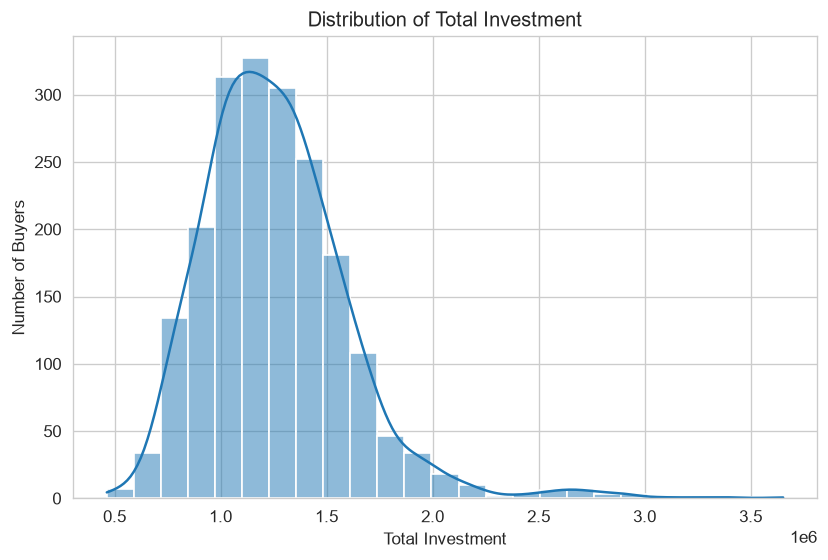

In [72]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=master,
    x="total_investment",
    bins=25,
    kde=True
)

plt.title("Distribution of Total Investment")
plt.xlabel("Total Investment")
plt.ylabel("Number of Buyers")

plt.show()

### Business Insight

- Most buyers fall within a specific investment range.
- A small number of buyers contribute significantly higher investments, indicating potential premium investor segments.

In [73]:
master["total_investment"].describe()

count    2.000000e+03
mean     1.260375e+06
std      3.478307e+05
min      4.636120e+05
25%      1.025238e+06
50%      1.220893e+06
75%      1.441974e+06
max      3.653385e+06
Name: total_investment, dtype: float64

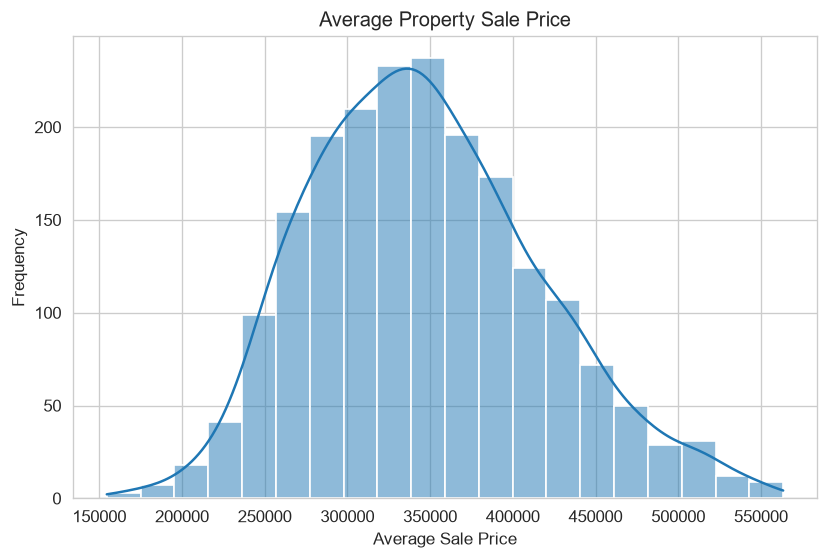

In [74]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=master,
    x="average_sale_price",
    bins=20,
    kde=True
)

plt.title("Average Property Sale Price")
plt.xlabel("Average Sale Price")
plt.ylabel("Frequency")

plt.show()

### Business Insight

- Average property prices help identify the affordability range preferred by buyers.
- Extreme values may represent luxury property purchases.

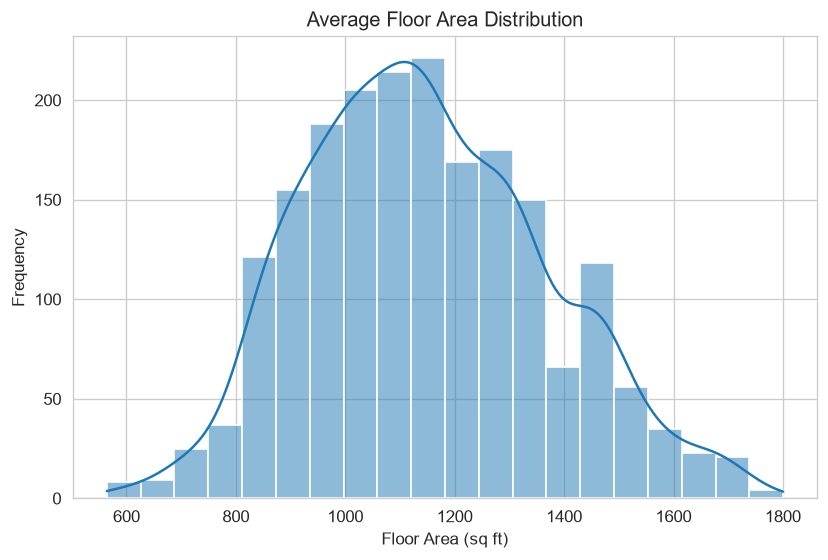

In [75]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=master,
    x="average_floor_area",
    bins=20,
    kde=True
)

plt.title("Average Floor Area Distribution")
plt.xlabel("Floor Area (sq ft)")
plt.ylabel("Frequency")

plt.show()

### Business Insight

- Buyers purchasing larger properties may represent premium or investment-oriented customers.

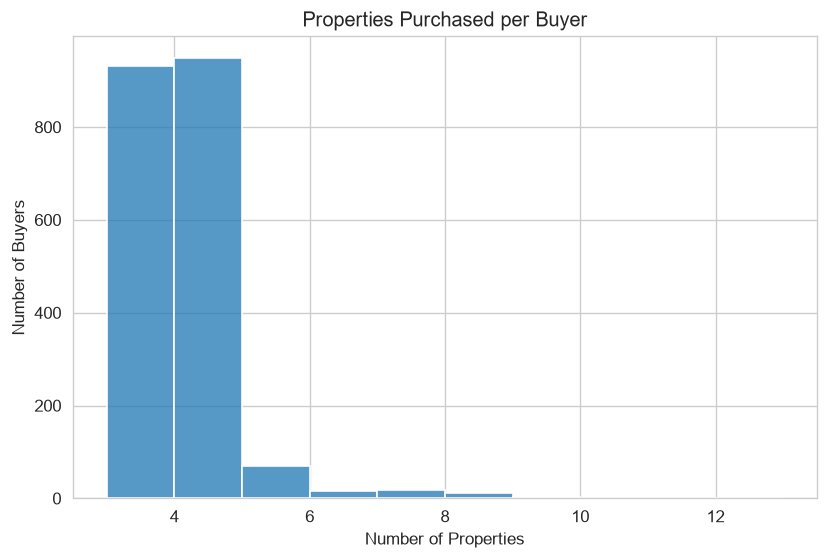

In [76]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=master,
    x="total_properties",
    bins=10
)

plt.title("Properties Purchased per Buyer")
plt.xlabel("Number of Properties")
plt.ylabel("Number of Buyers")

plt.show()

### Business Insight

- Buyers purchasing multiple properties are potential long-term investors or corporate clients.

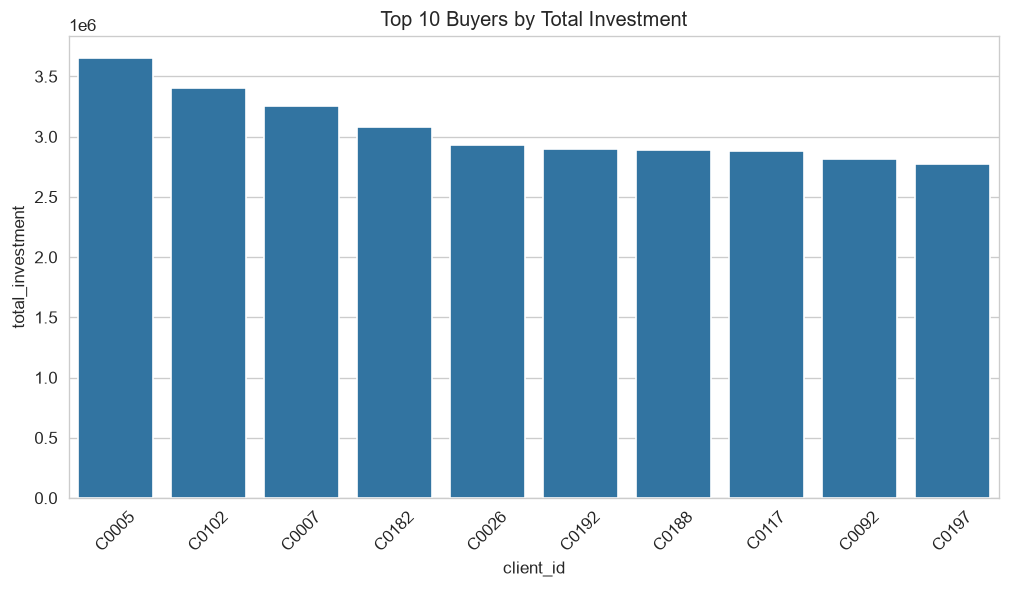

In [77]:
top10 = (
    master
    .sort_values(
        by="total_investment",
        ascending=False
    )
    .head(10)
)

plt.figure(figsize=(10,5))

sns.barplot(
    data=top10,
    x="client_id",
    y="total_investment"
)

plt.title("Top 10 Buyers by Total Investment")

plt.xticks(rotation=45)

plt.show()

### Business Insight

- These buyers contribute the highest investment values and represent high-priority customers for premium marketing campaigns.

In [78]:
top10[
    [
        "client_id",
        "client_type",
        "country",
        "total_investment"
    ]
]

,client_id,client_type,country,total_investment
4,C0005,Company,USA,3653385.38
101,C0102,Individual,USA,3403263.85
6,C0007,Individual,Canada,3251147.83
181,C0182,Individual,Germany,3082362.35
25,C0026,Individual,USA,2932241.75
191,C0192,Individual,Belgium,2900509.10
187,C0188,Individual,USA,2891447.60
116,C0117,Individual,UK,2884556.25
91,C0092,Individual,USA,2817926.96
196,C0197,Individual,USA,2775768.60


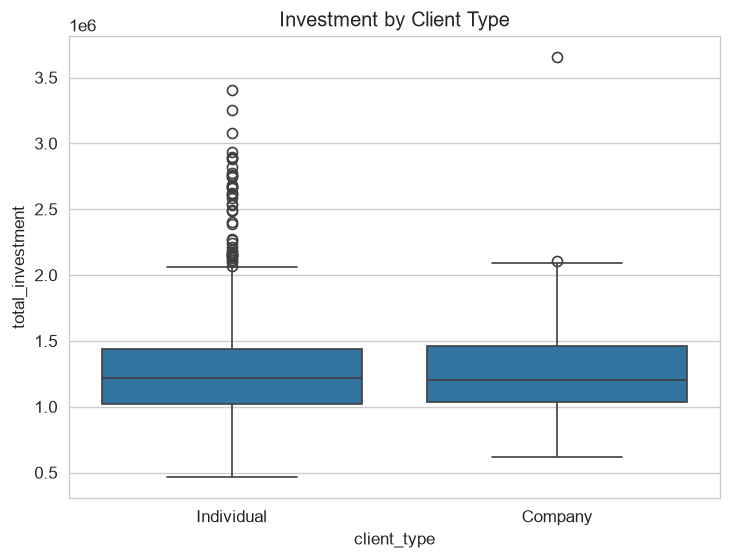

In [79]:
plt.figure(figsize=(7,5))

sns.boxplot(
    data=master,
    x="client_type",
    y="total_investment"
)

plt.title("Investment by Client Type")

plt.show()

### Business Insight

- Corporate buyers generally tend to purchase larger or multiple properties.
- Individual buyers usually represent a broader range of investment values.

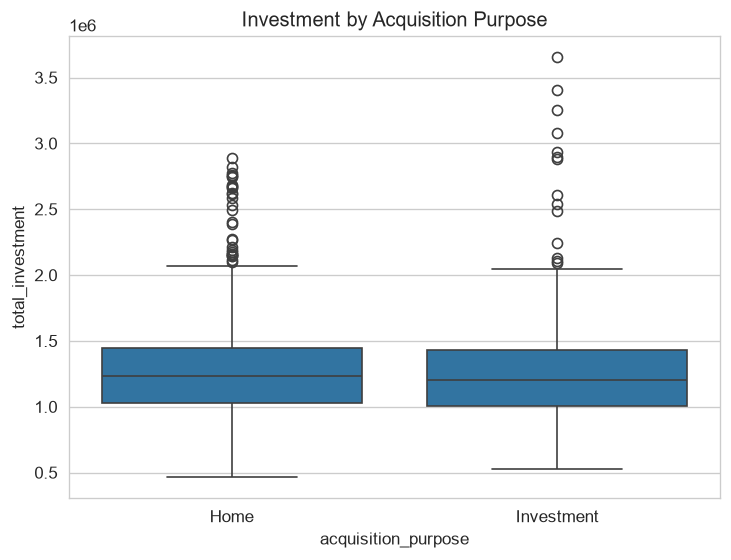

In [80]:
plt.figure(figsize=(7,5))

sns.boxplot(
    data=master,
    x="acquisition_purpose",
    y="total_investment"
)

plt.title("Investment by Acquisition Purpose")

plt.show()

### Business Insight

- Investment-oriented buyers are expected to exhibit higher spending patterns than buyers purchasing for personal use.

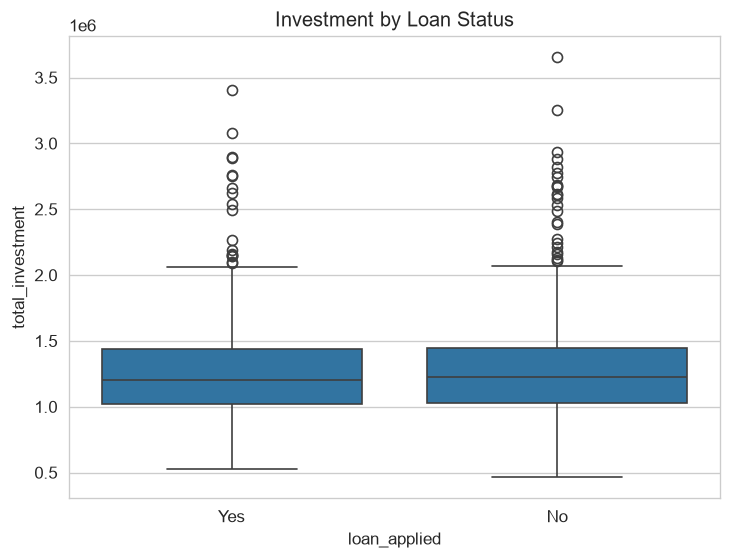

In [81]:
plt.figure(figsize=(7,5))

sns.boxplot(
    data=master,
    x="loan_applied",
    y="total_investment"
)

plt.title("Investment by Loan Status")

plt.show()

### Business Insight

- Loan dependency provides insights into financing behavior and purchasing capacity.

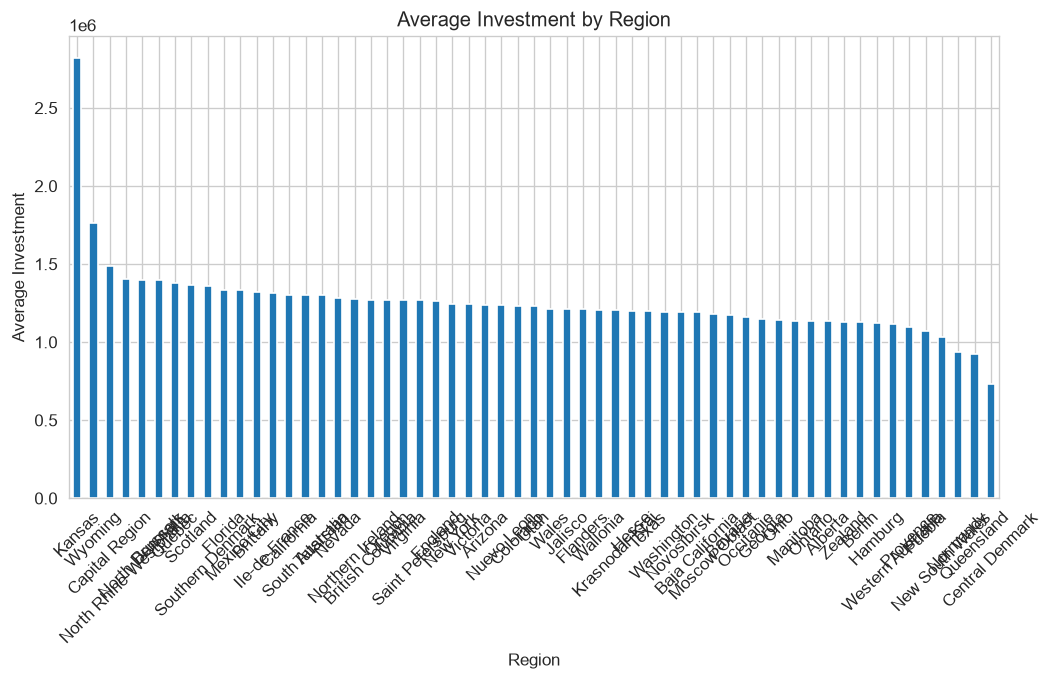

In [82]:
investment_region = (
    master
    .groupby("region")["total_investment"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10,5))

investment_region.plot(
    kind="bar"
)

plt.title("Average Investment by Region")
plt.xlabel("Region")
plt.ylabel("Average Investment")

plt.xticks(rotation=45)

plt.show()

### Business Insight

- Regions with higher average investments may represent premium real estate markets.

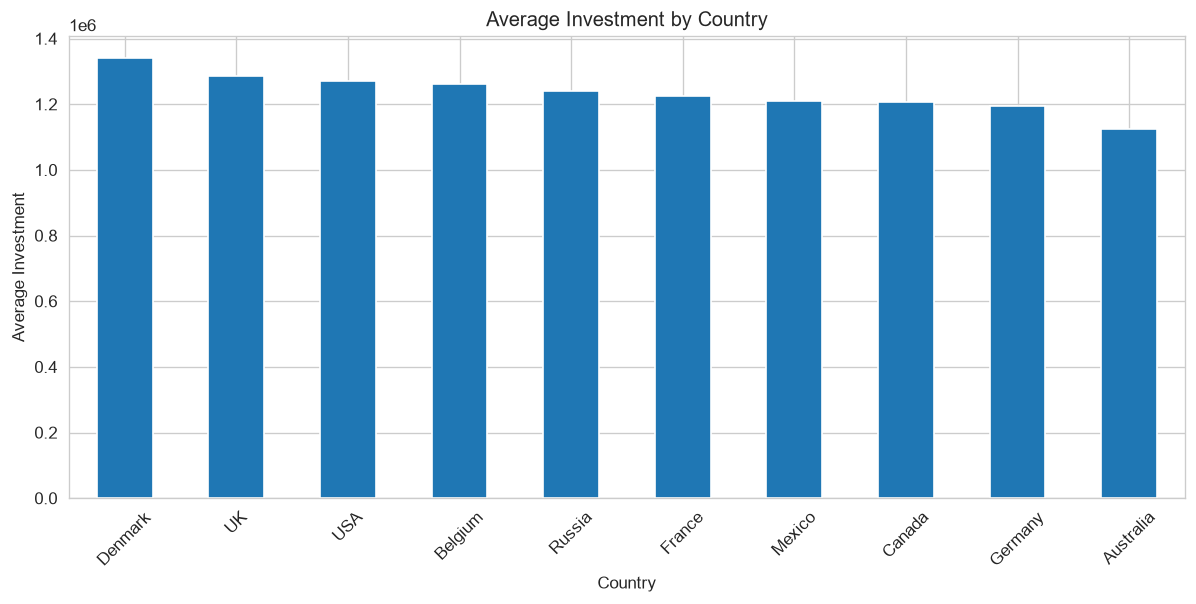

In [83]:
investment_country = (
    master
    .groupby("country")["total_investment"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12,5))

investment_country.plot(
    kind="bar"
)

plt.title("Average Investment by Country")
plt.xlabel("Country")
plt.ylabel("Average Investment")

plt.xticks(rotation=45)

plt.show()

### Business Insight

- Country-level investment analysis highlights markets with stronger purchasing power.

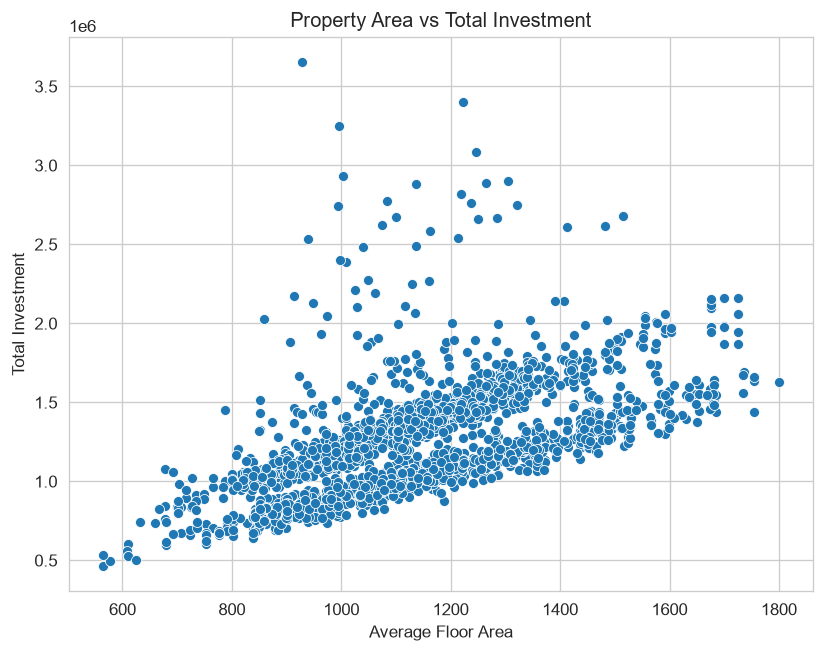

In [84]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=master,
    x="average_floor_area",
    y="total_investment"
)

plt.title("Property Area vs Total Investment")
plt.xlabel("Average Floor Area")
plt.ylabel("Total Investment")

plt.show()

### Business Insight

- Buyers purchasing larger properties generally invest more, although exceptions may indicate pricing differences across markets.

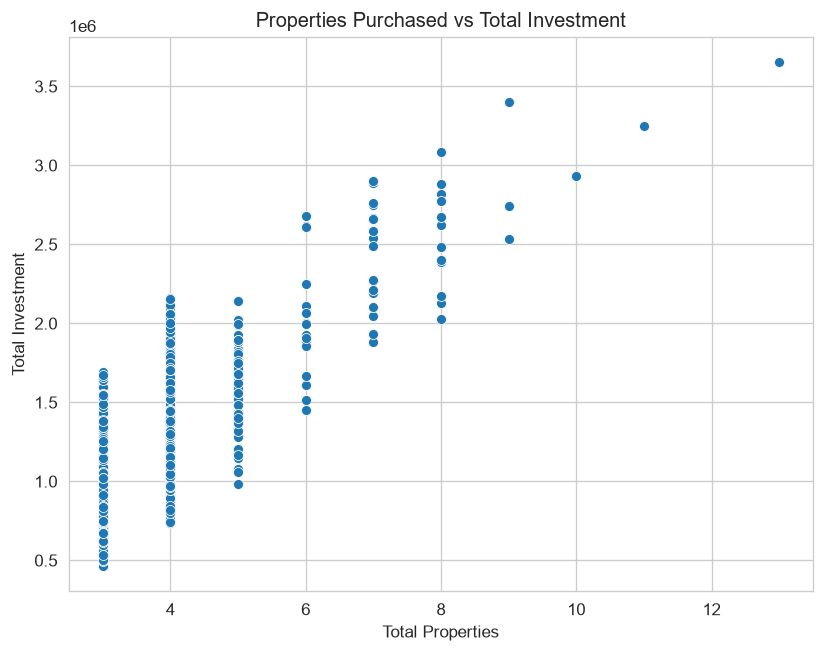

In [85]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=master,
    x="total_properties",
    y="total_investment"
)

plt.title("Properties Purchased vs Total Investment")
plt.xlabel("Total Properties")
plt.ylabel("Total Investment")

plt.show()

### Business Insight

- Buyers purchasing multiple properties are more likely to belong to investor or corporate segments.

## Part 3 Summary

This section analyzed buyer investment behavior and purchasing characteristics.

### Key Findings

- Distribution of investment values explored.
- Property purchase frequency analyzed.
- High-value buyers identified.
- Investment differences across client types examined.
- Regional and country-wise investment patterns explored.
- Relationship between property characteristics and investment studied.

These insights form the foundation for buyer segmentation using machine learning clustering techniques.

# Relationship Analysis & Feature Selection

This section examines relationships among variables, detects outliers, and identifies the most suitable features for clustering models.

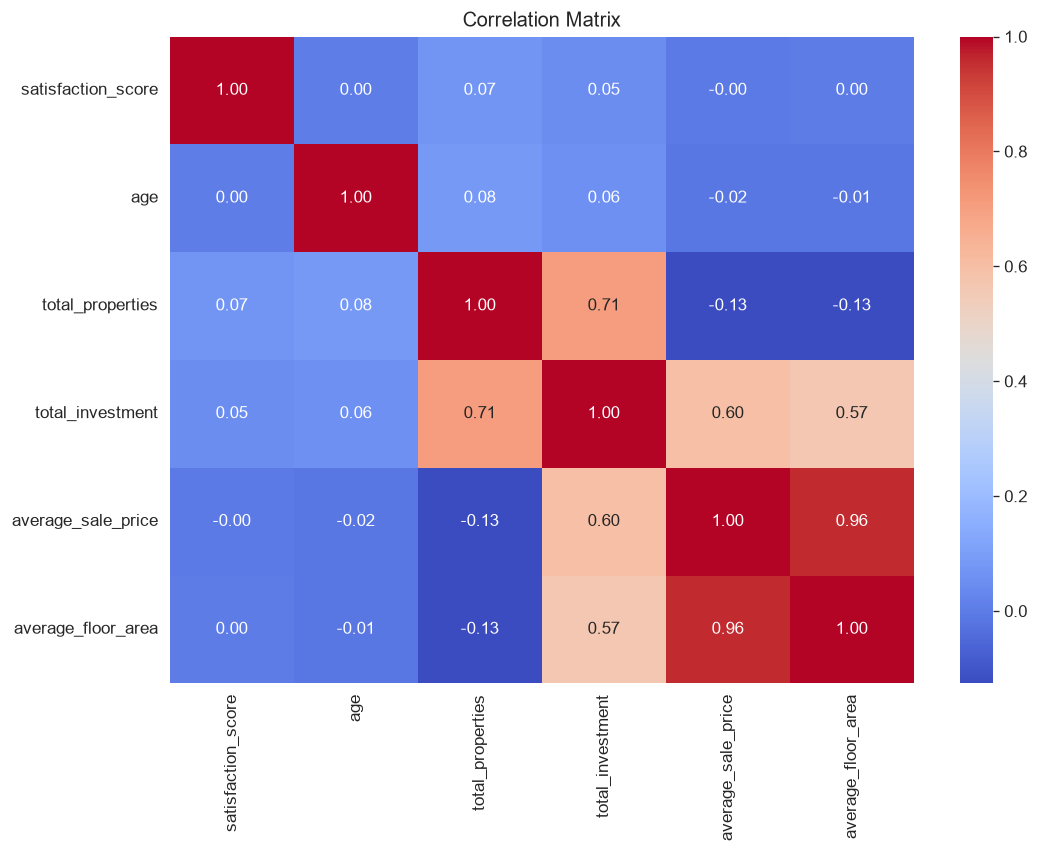

In [86]:
plt.figure(figsize=(10,7))

numeric = master.select_dtypes(include="number")

sns.heatmap(
    numeric.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.show()

### Business Insight

- The correlation matrix identifies relationships among numerical variables.
- Highly correlated variables may represent similar buyer characteristics.
- Weak correlations indicate independent behavioral factors useful for clustering.

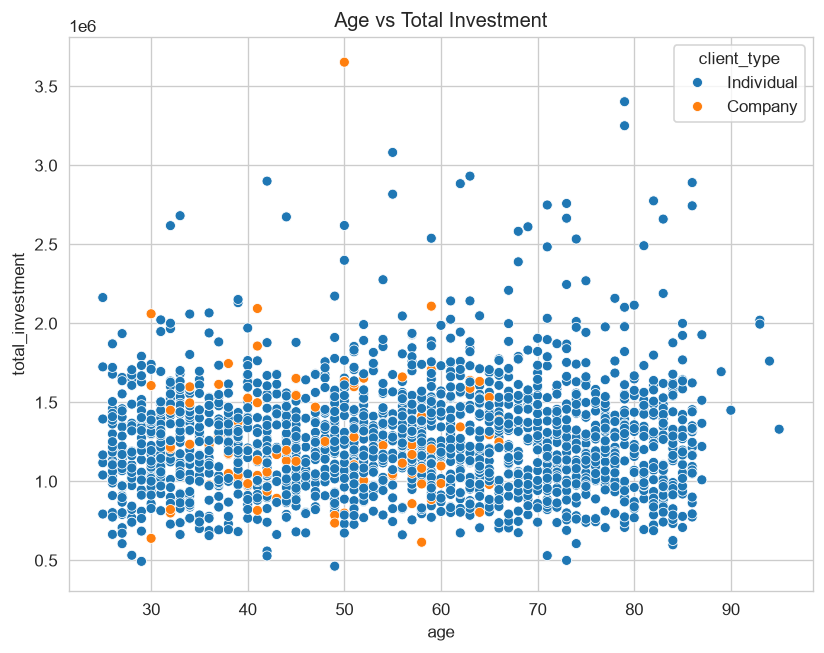

In [87]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=master,
    x="age",
    y="total_investment",
    hue="client_type"
)

plt.title("Age vs Total Investment")

plt.show()

### Business Insight

- This visualization explores whether investment increases with buyer age.
- It also highlights differences between individual and company buyers.

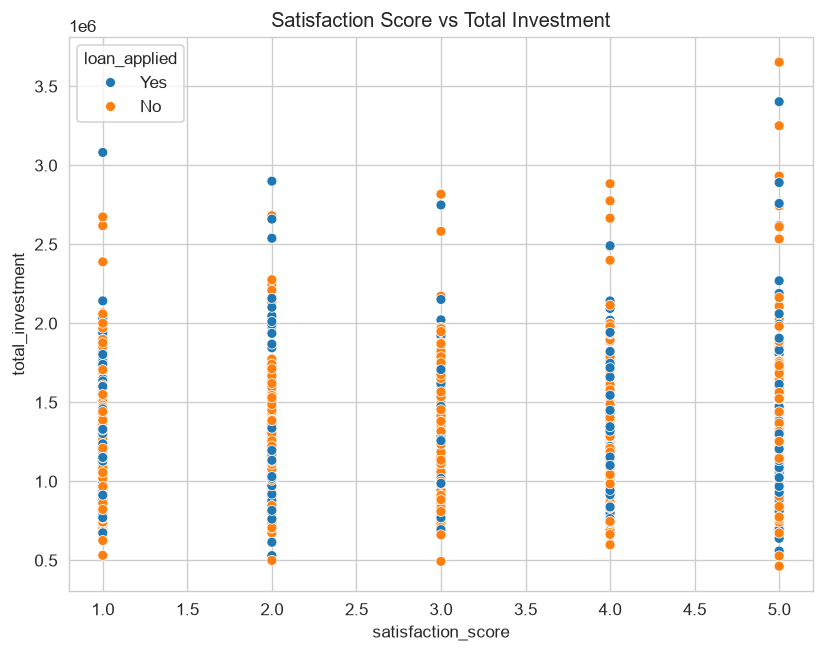

In [88]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=master,
    x="satisfaction_score",
    y="total_investment",
    hue="loan_applied"
)

plt.title("Satisfaction Score vs Total Investment")

plt.show()

### Business Insight

- Higher investments do not always correspond to higher customer satisfaction.
- This insight may reveal opportunities to improve premium customer experience.

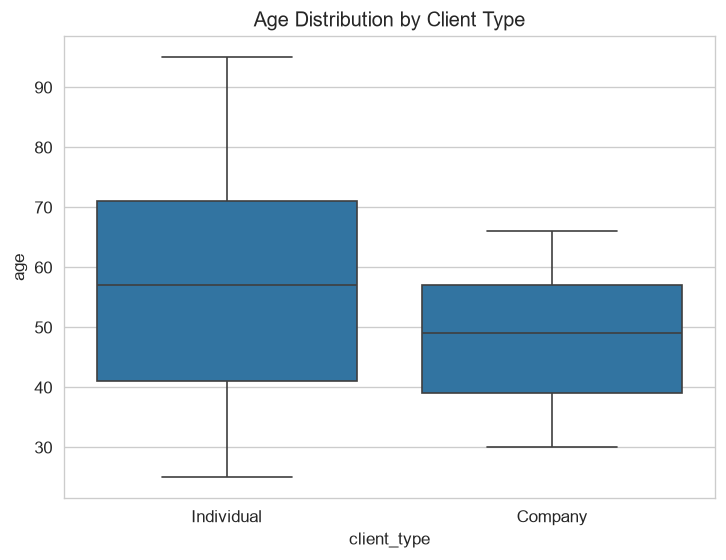

In [89]:
plt.figure(figsize=(7,5))

sns.boxplot(
    data=master,
    x="client_type",
    y="age"
)

plt.title("Age Distribution by Client Type")

plt.show()

### Business Insight

- Age profiles differ across buyer categories.
- This supports age-specific marketing and segmentation strategies.

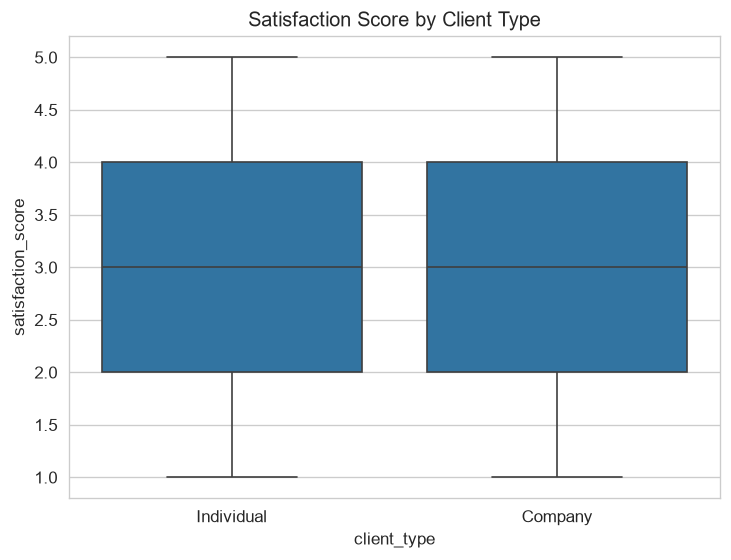

In [90]:
plt.figure(figsize=(7,5))

sns.boxplot(
    data=master,
    x="client_type",
    y="satisfaction_score"
)

plt.title("Satisfaction Score by Client Type")

plt.show()

### Business Insight

- Customer satisfaction may vary between individual and company buyers.
- Identifying these differences can improve customer relationship management.

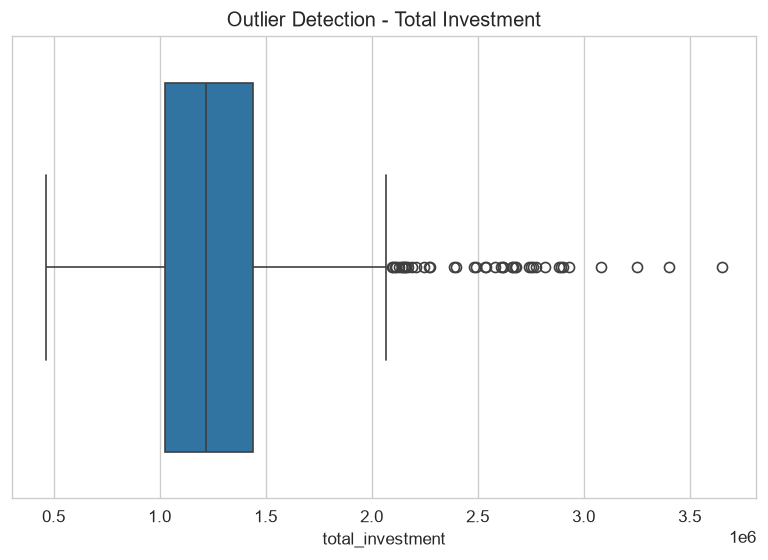

In [91]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x=master["total_investment"]
)

plt.title("Outlier Detection - Total Investment")

plt.show()

### Business Insight

- High-value outliers may represent luxury or institutional investors.
- These buyers should not be removed automatically because they may form meaningful clusters.

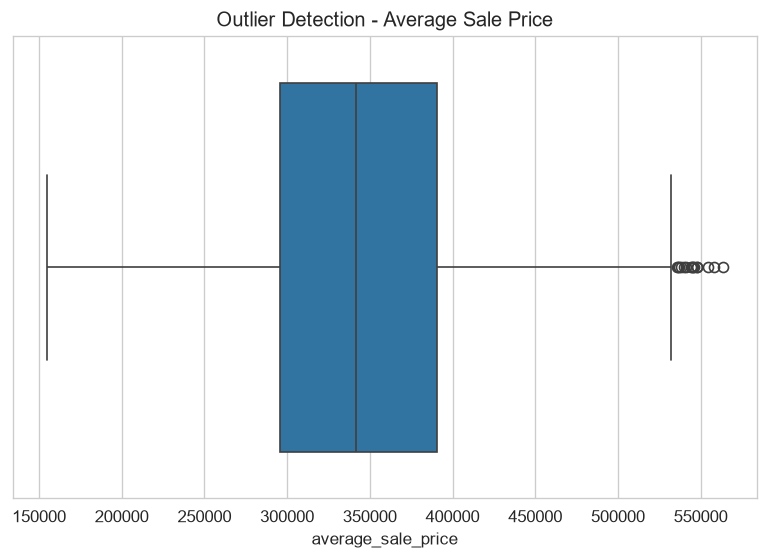

In [92]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x=master["average_sale_price"]
)

plt.title("Outlier Detection - Average Sale Price")

plt.show()

### Business Insight

- Premium properties naturally create higher sale-price values.
- These observations are important for identifying luxury buyer segments.

In [93]:
feature_columns = [
    "age",
    "satisfaction_score",
    "total_properties",
    "total_investment",
    "average_sale_price",
    "average_floor_area"
]

master[feature_columns].head()

,age,satisfaction_score,total_properties,total_investment,average_sale_price,average_floor_area
0,57,4,4,1246764.72,311691.180000,983.885000
1,63,1,5,1841095.93,368219.186000,1187.942000
2,67,4,5,1661457.59,332291.518000,1058.110000
3,66,5,6,1608263.51,268043.918333,937.103333
4,50,5,13,3653385.38,281029.644615,927.296154


### Observation

These numerical variables represent buyer demographics, purchasing capacity and investment behavior. They will be standardized before clustering.

In [94]:
categorical_features = [
    "client_type",
    "gender",
    "country",
    "region",
    "acquisition_purpose",
    "loan_applied",
    "referral_channel"
]

master[categorical_features].head()

,client_type,gender,country,region,acquisition_purpose,loan_applied,referral_channel
0,Individual,F,USA,California,Home,Yes,Website
1,Individual,M,USA,California,Home,No,Website
2,Individual,M,USA,California,Home,Yes,Agency
3,Individual,M,USA,California,Home,No,Website
4,Company,M,USA,California,Investment,No,Website


### Observation

These categorical variables describe buyer characteristics and will be encoded using appropriate encoding techniques before applying clustering algorithms.

In [95]:
master.to_csv("../data/master_dataset.csv", index=False)

print("Master dataset saved successfully.")

Master dataset saved successfully.


# Overall EDA Conclusion

The exploratory data analysis provided comprehensive insights into buyer demographics, investment behavior, financing patterns and geographic distribution.

### Major Findings

- Buyer demographics and customer composition were analyzed.
- Geographic trends were identified across countries and regions.
- Investment behavior and purchasing capacity were explored.
- Relationships among numerical variables were examined.
- Outliers were identified and interpreted as potential premium buyer groups.
- Features for machine learning clustering were finalized.

The dataset is now ready for feature encoding, scaling and clustering using K-Means and Hierarchical Clustering.